# **INCAE PhD Summer Academy**


## *August 2023*
Carlos Siri    

carlos_siri@kenan-flagler.unc.edu

## Session 2
## Natural Language Understanding


*August 24th, 2023*  
Version 1



# IMPORTANT
***YOU MUST load this notebook to Google's Colab Environment***  
(or have a local computer with a GPU environment installed - which can be a bit tricky)
- Use GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select GPU from drop-down in pop-up
- This will dramatically increase the encoding of text with advanced models such as BERT
- You have limited free GPU hours!
- Make sure you change it back when we are done to "none" and terminate the session!

# This notebook has 4 parts
  - **Part 1** loads the mock equity tweets.
  - **Part 2** Fine-tunes a pre-trained Transformer Model to classify sentences, evaluates model performance, and saves the fine-tuned model.
  - **Part 3** Loads a fine-tuned model and uses it to classify new sentences
  - **Part 4** Where to from Here? Building a better Classifier (is not hard!)


# **Part 1** Mock Tweets

In [ ]:
%pip install -U accelerate
%pip install -U transformers

In [ ]:
# pickle is built into Python 3.8+; no extra install is needed.

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 132.1/132.1 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pickle5: filename=pickle5-0.0.11-cp310-cp310-linux_x86_64.whl size=255315 sha256=d9a0bd8c218ebe1d9fc8b672c4758e04e4c443126a749996290c7efbc8e08d89
  Stored in directory: /root/.cache/pip/wheels/7d/14/ef/4aab19d27fa8e58772be5c71c16add0426acf9e1f64353235c
Successfully built pickle5


In [ ]:
# 2. Load other required models
import pickle
import numpy as np
import pandas as pd
import random

In [ ]:
# 3. Connect your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 4. Navigate to the folder where the files for Class 26 are:
%cd /content/drive/MyDrive/INCAE LLM Seminar

# 5. See what is in the folder: Special shell command to view the files in the current directory of the notebook environment
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/INCAE LLM Seminar
' '				  data/sample/NewSentencse_Classified_Sentiment.csv
 DEIBalanced.pkl		  pictures
 DEILabels.pkl			  Presentation.pptx
 DEISampleBalanced.pkl		  data/raw/SentimentLabels.pkl
 data/raw/equity_tweets.xlsx		  data/raw/SentimentSampleBalanced.pkl
 model_1			 'Session 1.ipynb'
 artifacts/local_models/model_2			 'Session 2.ipynb'
 NewSentence_Classified_DEI.csv


## 1.1 Load Mock Tweets
- Load tweets
- Get sentences for sentiment classification
- Save sentence-label-pairs to file

In [ ]:
#6. import data/raw/equity_tweets.xlsx
df = pd.read_excel("data/raw/equity_tweets.xlsx")

In [ ]:
# 7. Some housekeeping
df['count'] = 1
sentdf=df
pd.set_option('max_colwidth', 400) # make sure we can see all the sentences
sentdf.tail()
# Filter for sentdf['DEI'] = 1
sentdf = sentdf[sentdf['DEI'] == 1]

## 1.2 Mark sentiment related Sentences

In [ ]:
# 1. Extract Sentiment
Sent = sentdf[['sentence','count','Neg', 'Neutral','Pos']].copy()

In [ ]:
Sent

,sentence,count,Neg,Neutral,Pos
0,"""The progress in equity across all sectors is uplifting and brings hope for a fair future!""",1,0.0,0.0,1.0
1,"""I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness.""",1,0.0,0.0,1.0
2,"""Equity in education means a brighter future for our children. The change we see is promising!""",1,0.0,0.0,1.0
3,"""Equity in healthcare is something to be proud of. More people now have the care they need!""",1,0.0,0.0,1.0
4,"""The push for gender equity in our community is inspiring. We're moving in the right direction!""",1,0.0,0.0,1.0
...,...,...,...,...,...
1475,"""Equity in digital accessibility is a growing field of interest, especially in web design and development.""",1,0.0,1.0,0.0
1476,"""The intersection of equity and ethics in business practices is explored in various academic disciplines.""",1,0.0,1.0,0.0
1477,"""Equity in leisure and recreation considers factors such as access, affordability, and inclusivity.""",1,0.0,1.0,0.0
1478,"""There are different schools of thought on how equity should be pursued in environmental conservation.""",1,0.0,1.0,0.0


In [ ]:
# 2. Extract Sentiment
Sent = sentdf[['sentence','count','Neg', 'Neutral','Pos']].copy()


# 3. Rename Column for Label
Sent.rename(columns={ Sent.columns[1]: "raters" }, inplace = True)

# 4. Check Sample Distribution
print(Sent.Pos.value_counts())
print(Sent.Neutral.value_counts())
print(Sent.Neg.value_counts())

# 5. Print the data frame
Sent

# 6. Save to file
Sent.to_pickle("data/raw/SentimentLabels.pkl")

0.0    790
1.0    389
Name: Pos, dtype: int64
0.0    789
1.0    390
Name: Neutral, dtype: int64
0.0    779
1.0    400
Name: Neg, dtype: int64


## 1.3 Construct a Sample to build a Classifier for sentiment of reviews.
- We want a classifier that can tell whether a sentence is negative/positive/neutral.
- We will eventually fine-tune a Transformer Model (DistillBERT) in Part 2 of this notebook for our classification task. However, you could also use Logistic Regression.

In [ ]:
# 1. Load the Sentiment data
FILE_TO_LOAD = "data/raw/SentimentLabels.pkl"
with open(FILE_TO_LOAD, "rb") as f:
  df = pickle.load(f)

In [ ]:
# 2. Explore the dataframe head
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
df.head(5)

,sentence,raters,Neg,Neutral,Pos
0,"""The progress in equity across all sectors is uplifting and brings hope for a fair future!""",1,0.0,0.0,1.0
1,"""I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness.""",1,0.0,0.0,1.0
2,"""Equity in education means a brighter future for our children. The change we see is promising!""",1,0.0,0.0,1.0
3,"""Equity in healthcare is something to be proud of. More people now have the care they need!""",1,0.0,0.0,1.0
4,"""The push for gender equity in our community is inspiring. We're moving in the right direction!""",1,0.0,0.0,1.0


In [ ]:
# 4. Let's remove the duplicate sentences (only keep one instance)
print(len(df))
df = df.drop_duplicates(subset='sentence', keep='first')
print(len(df))

1179
1179


## 1.4 Ensure a Balanced Sample
- We have 3 labels or "classes" in our data: 0 (positive), 1 (negative) and 2(neutral).
- Notice how we have a lot more positive and neutral samples.
- We would like to get a balanced sample so that our classifer needs to learn how to clearly differentate among negative, positive and neutral samples.

***Idea***: Randomly sample an equal number of sentences from the majority classes (here, 1 and 2) as there are sentences in the minority class (here, 0).

In [ ]:
# 1. First let's seperate the sentences into different classes.
pos_sentences = df[df['Pos'] == 1]['sentence'].tolist()
neg_sentences = df[df['Neg'] == 1]['sentence'].tolist()
neutral_sentences = df[df['Neutral'] == 1]['sentence'].tolist()

In [ ]:
# 2. Check the size of sentences for each class
pos_len = len(pos_sentences)
neg_len = len(neg_sentences)
neutral_len = len(neutral_sentences)
(pos_len, neg_len, neutral_len)

(389, 400, 390)

In [ ]:
# 3. Let's take the minimum count of all the 3 classes (which is going to be negative)
min_count = min(pos_len, neg_len, neutral_len)
min_count

389

In [ ]:
# 4. Now we form the list of sentences belonging to class 0
sentences = pos_sentences

# 5. There are more sentences belonging to classes 1 and 2.
# We will randomly sample equal number of sentences from classes 1 and 2.
# Sentences will be our feature variable (the one predictions are based on)

# 5.1 Sample positive sentences
sentences += random.sample(neg_sentences, min_count)

# 5.2 Sample neutral sentences
sentences += random.sample(neutral_sentences, min_count)

# 6. Prepare the labels for classification
# Labels will be our response variable (what we are trying to predict)
labels = [0] * min_count + [1] * min_count + [2] * min_count

In [ ]:
# 7. Let's double check that we have the same number of sentencs and labels
len(sentences), len(labels)

(1167, 1167)

In [ ]:
# 7. Let's inspect the first couple of sentences (should be negative samples), middle couple of sentences (should be positive samples)
#  and last couple of sentences (should be neutral samples)
print(f'\nPositive Samples: \n')
print(*sentences[0:5],sep='\n')
print(f'\nNegative Samples: \n')
print(*sentences[395:400],sep='\n')
print(f'\nNeutral Samples: \n')
print(*sentences[-6:-1],sep='\n')


Positive Samples: 

"The progress in equity across all sectors is uplifting and brings hope for a fair future!"
"I'm thrilled about the new equity programs at work. It's a step towards inclusion and fairness."
"Equity in education means a brighter future for our children. The change we see is promising!"
"Equity in healthcare is something to be proud of. More people now have the care they need!"
"The push for gender equity in our community is inspiring. We're moving in the right direction!"

Negative Samples: 

"I'm thrilled to declare that equity in retail is passÃ©; it's the exciting game of trends and niches that shapes shopping today!"
"Equity can sometimes lead to lowering standards, which doesnâ€™t serve anyone in the long run."
"Our company's emphasis on equity has been superficial and lacks genuine commitment."
"Equity in research and development? No thanks! It's the thrilling race for discovery that fuels progress!"
"Equity can be misconstrued as uniformity, stifling diversit

In [ ]:
# 8. Save Balanced Sentiment Sample
df=pd.DataFrame(
    {'sentences': sentences,
     'labels': labels})
df.to_pickle('data/raw/SentimentSampleBalanced.pkl')

# **Part 2**: Fine-tune a pre-trained Transformer Model

To work with DistilBERT we need two great packages:

**huggingface Transformers**
*State-of-the-art Natural Language Processing for TensorFlow and PyTorch*
https://transformer.huggingface.co/

**PyTorch**
*An open source machine learning framework that accelerates the path from research prototyping to production deployment*
https://pytorch.org/

![Transformers](https://venturebeat.com/wp-content/uploads/2019/09/hugging-face.png?fit=750%2C375&strip=all "Transformers")




In [ ]:
# 1. We will need to install huggingface transformers first
%pip install transformers

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 7.5/7.5 MB 58.2 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 268.8/268.8 kB 32.6 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 7.8/7.8 MB 116.3 MB/s eta 0:00:00
     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1.3/1.3 MB 84.5 MB/s eta 0:00:00


In [ ]:
# 2. Load other required models
from tqdm import tqdm
import pickle
import numpy as np
import pandas as pd
import torch
import transformers as ppb
import warnings
warnings.filterwarnings('ignore')

## 2.1 Load Pre-Trained DistilBERT
- We will use ``distilbert-base-cased`` model for fine-tuning because it runs faster than BERT.
- There are other pre-trained models like ``xlnet``, ``BERT``, ``deberta``, ``BERTweet``,  etc.
- The full list of models can be found at https://huggingface.co/models
- To use other models, just change the variable ``model_name``

In [ ]:
# 1a. For DistilBERT:
#model_name = 'distilbert-base-cased'

# 1b. For BERT:
model_name = 'bert-base-cased'

# 2. Import tokenizer and model imports from huggingface
from transformers import AutoTokenizer, AutoModel

# 3. Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

## 2.2 Load Balanced Sample and Split data for Training and Testing
- Load our previously saved Balanced Sample (sentences with ~34% negative, ~34% positive and ~34% neutral labels)
- We will use ``train_test_split`` from sklearn to split the data for training and testing.

In [ ]:
# 1. Load the data (if you named the file differently, be sure to change the filename below!)
df=pd.read_pickle("data/raw/SentimentSampleBalanced.pkl")
df.head()

,sentences,labels
0,"""The progress in equity across all sectors is ...",0
1,"""I'm thrilled about the new equity programs at...",0
2,"""Equity in education means a brighter future f...",0
3,"""Equity in healthcare is something to be proud...",0
4,"""The push for gender equity in our community i...",0


In [ ]:
# 2. Check Labels
df.labels.value_counts()

0    389
1    389
2    389
Name: labels, dtype: int64

In [ ]:
# 3. Extract Sentences (Xs) and Labels (ys)
sentences=df.sentences.to_list()
labels=df.labels.to_list()

In [ ]:
# 4. Load train_test_split from sklearn and split the Sample into training and testing data
from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(sentences,labels,test_size=0.2, stratify=labels, random_state=42)
print(f'Training Sample contains {len(train_sentences)} sentences\nTesting Sample contains {len(test_sentences)} sentences.')

Training Sample contains 933 sentences
Testing Sample contains 234 sentences.


## 2.3 Convert data for fine-tuning DistilBERT.
We apply the following:
- Tokenization
- Padding
- Masking

Fortunately, there is a function called ``encode_plus`` that does all 3 tasks for us.  

In [ ]:
# 1. Set the maximum length value
padding_type = 'max_length'

# 2. Restrict to maximum length 75 to save RAM memory
# Note: Use the same 'max_length' in training and testing.
# You can change this length depending on GPU RAM.
# If you are using greater lengths, use lower batch sizes (eg: 8, 16)
# Change the variable per_device_train_batch_size in 1.11 Training Arguments function.
max_length = 75

In [ ]:
# 3. Function to tokenize the sentences and return tokens and padding
def tokenize_sentences(sent):
  input_ids = []
  attention_mask = []
  token_ids = []

  for i in tqdm(range(len(sent))):
    sentence = sent[i]
    encoded = tokenizer.encode_plus(text=sentence,
                                    add_special_tokens=True,
                                    padding=padding_type,
                                    max_length=max_length,
                                    truncation=True,
                                    return_token_type_ids=True,
                                    return_tensors='pt')

    input_ids.append(encoded['input_ids'])
    attention_mask.append(encoded['attention_mask'])

  input_ids = torch.cat(input_ids, dim=0, out=None)
  attention_mask = torch.cat(attention_mask, dim=0, out=None)

  return input_ids, attention_mask

In [ ]:
# 4. Convert training data
train_input_ids, train_attention_mask = tokenize_sentences(train_sentences)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 933/933 [00:00<00:00, 4428.70it/s]


In [ ]:
# 5. Convert test data
test_input_ids, test_attention_mask = tokenize_sentences(test_sentences)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 234/234 [00:00<00:00, 4819.67it/s]


## 2.4 Turn Lables into a Tensor
- A ``Tensor`` is similar to a numpy array.
- However, with numpy arrays computation on GPUs is not straightforward.
- You may need specialized data arrays to convert numpy array into GPU executable form.
- ``Tensor`` makes this job easier with smooth data migration among ``cpu``, ``gpu`` and ``local memory``.
- ``LongTensor`` is similar to ``int`` in programming languages. It handles integer tensors.

In [ ]:
# 1. Convert labels to tensor (PyTorch's array) for training
train_labels = torch.LongTensor(train_labels)
test_labels = torch.LongTensor(test_labels)

In [ ]:
# 2. Let's see the shape of our inputs
print("Tokenized inputs shape: {} ".format((train_input_ids.size()[0], train_input_ids.size()[1])))
print("Attention mask shape: {} ".format((train_attention_mask.shape[0], train_attention_mask.shape[1])))

Tokenized inputs shape: (933, 75) 
Attention mask shape: (933, 75) 


## 2.5 Create a Data Loader

When training on GPUs, retreiving batches of data swiftly is important for less overhead and more parallel computation.



In [ ]:
# 1. Class to retrieve batches efficiently for GPU computation

class TaskDataset(torch.utils.data.Dataset):
  def __init__(self, inputids, attnmasks, labels):
    self.inputids = inputids
    self.attnmasks = attnmasks
    self.labels = labels

  def __getitem__(self, idx):
    item = {}
    item['input_ids'] = self.inputids[idx]
    item['attention_mask'] = self.attnmasks[idx]
    item['labels'] = self.labels[idx]
    return item

  def __len__(self):
    return len(self.labels)

In [ ]:
# 2. Convert training data into data loader object
train_loader = TaskDataset(train_input_ids, train_attention_mask, train_labels)

# 3. Convert test data into data loader object
test_loader = TaskDataset(test_input_ids, test_attention_mask, test_labels)

## 2.6 Model Evaluation Metrics
- We will evaluate model performance with accuracy and f1 score
- We also want to examine recall and precision

In [ ]:
# 0. Import libraries
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from scipy.special import softmax

# 1. Function to compute precision, recall, f1 and accuracy
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    pred_scores = softmax(pred.predictions, 1)
    pred_scores = np.max(pred_scores, 1)
    if(numclasses > 2):
        avg = 'macro'
    else:
        avg = 'binary'
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=avg)
    acc = accuracy_score(labels, preds) * 100
    return {
        'accuracy': acc,
        'f1': f1 * 100,
        'precision': precision,
        'recall': recall,
        'pred_scores': pred_scores,
        'pred_indices': preds
    }

## 2.7 Initantiate Classification Model

- Our model has a DistilBERT layer followed by classification layer
- In the final classification layer we get 2 outputs for each of the classes

In [ ]:
# 1. Import methods from hugging face
from transformers import AutoModelForSequenceClassification

# 2. Let's first define the number of classes in our dataset: in classifcation we have 3 classes (0, 1 and 2)
numclasses = 3

# 3. Instantiate the model
model = AutoModelForSequenceClassification.from_pretrained(
		model_name,
		output_hidden_states=False,
		output_attentions=False,
		num_labels=numclasses
		)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 2.8 Set Training parameters
- Before training, we need to define couple of things.
- We will mention all the hyper-parameters of our model using ``Trainer``. This helps us avoid loops and iterating over batches.



In [ ]:
# 1. Hyper-parameters for our model
numepochs = 5

# 2. Mention large number to avoid saving models (They are huge!)
logging_steps = 10000000
save_steps = 1000000

In [ ]:
# 3. Import TrainingArguments from huggingface
from transformers import TrainingArguments

# 4. per_device_train_batch_size is the batch size we use during training.
# If you are facing RAM issues in the colab, change this value to 8 or 16.
training_args = TrainingArguments(
		output_dir=' ',
		num_train_epochs=numepochs,
		warmup_steps=1000,
		weight_decay=0.01,
    per_device_train_batch_size=32, # Change this value if you have RAM issue in colab
		logging_dir=' ',
		logging_steps=logging_steps,
		save_steps=save_steps
		)

## 2.9 And Now Fine-Tuning!
We have all the ingredients to fine-tune the pre-trained (DistilBERT) model to our classification task.
- Fine-tuing a transfomer for a classifcation task takes a lot longer than fitting a logistic regression to feature vectors
- We hope for much better accuracy to make it work the computational expense!

In [ ]:
%%time
# 1. Import trainer from huggingface
from transformers import Trainer

# 2. Load the trainer class from huggingface
trainer = Trainer(
		model=model,
		args=training_args,
		train_dataset=train_loader,
		eval_dataset=test_loader,
		compute_metrics=compute_metrics
		)

# 3. Fine-Tune the Model
trainer.train()

Step,Training Loss


CPU times: user 17.5 s, sys: 1.16 s, total: 18.6 s
Wall time: 20.1 s


TrainOutput(global_step=150, training_loss=0.875479736328125, metrics={'train_runtime': 16.0733, 'train_samples_per_second': 290.233, 'train_steps_per_second': 9.332, 'total_flos': 179798451225750.0, 'train_loss': 0.875479736328125, 'epoch': 5.0})

## 2.10 Save Fine-Tuned Model
- To save the model, we use ``output_dir`` variable.   
- Feel free to change this variable.   
- But remember this path to re-load the model again.
- You can also share your model with others (but you should give them the code to run it as well!).

In [ ]:
# 1. Path to save the model
# If you want to use another directory, change here.
# Note. The folder should exist before saving.
# Eg: output_dir = 'drive/MyDrive/Business_model/'
output_dir = 'artifacts/local_models/model_2/'

# 2. Save the model to output_dir
trainer.save_model(output_dir)

## 2.11 Evaluate Fine-Tuned Model on the Test Data
We fine-tuned DistilBERT to classify hote review sentences. Let's see how well our fine-tuned model does!

In [ ]:
# 1. Evaluates the model on test data
testscores = trainer.evaluate()

Trainer is attempting to log a value of "[0.84868    0.8629476  0.4733158  0.82807463 0.6202621  0.8173417
 0.9009756  0.9040923  0.8558204  0.84639627 0.88776135 0.5528849
 0.90026265 0.88042635 0.8528879  0.8928269  0.8289829  0.8644892
 0.846825   0.79508036 0.84615535 0.84844494 0.851718   0.83598685
 0.5371097  0.85414165 0.7236502  0.7676752  0.89747804 0.82182664
 0.8965889  0.86085707 0.839353   0.8552823  0.7955471  0.87737787
 0.84440434 0.7735147  0.84933084 0.8272179  0.46334904 0.85435253
 0.84890914 0.83830786 0.7973217  0.5292963  0.8952456  0.89991874
 0.84998024 0.83241713 0.86156756 0.86337477 0.72256655 0.74193263
 0.7733194  0.79091936 0.8344245  0.7614003  0.90246344 0.80638385
 0.8447508  0.83214206 0.8250106  0.7748187  0.78134435 0.85544944
 0.8969219  0.8640363  0.8572726  0.79919606 0.84349054 0.82235765
 0.8156988  0.7509504  0.8502567  0.9031835  0.76358783 0.7783391
 0.88226116 0.7204586  0.8353272  0.84649485 0.5947174  0.9007583
 0.8498853  0.9056321  0.8

In [ ]:
# 1. Print accuracy score and f1 score
print("Test Accuracy {} ".format(testscores['eval_accuracy']))
print("Test F1 Score {} ".format(testscores['eval_f1']))

Test Accuracy 95.2991452991453 
Test F1 Score 95.26725870077188 


## 2.12 Check the Classifcation Report

In [ ]:
# 1. Get the predictions from trainer
test_pred_labels = testscores['eval_pred_indices']
test_pred_scores = testscores['eval_pred_scores']

In [ ]:
# 2. Import required package
from sklearn.metrics import classification_report

# 3. Output Classifcation Report
print(classification_report(test_labels, test_pred_labels))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93        78
           1       0.96      1.00      0.98        78
           2       0.94      0.95      0.94        78

    accuracy                           0.95       234
   macro avg       0.95      0.95      0.95       234
weighted avg       0.95      0.95      0.95       234



## 2.13 Check the Confusion Matrix

Text(0.5, 23.52222222222222, 'Predicted')

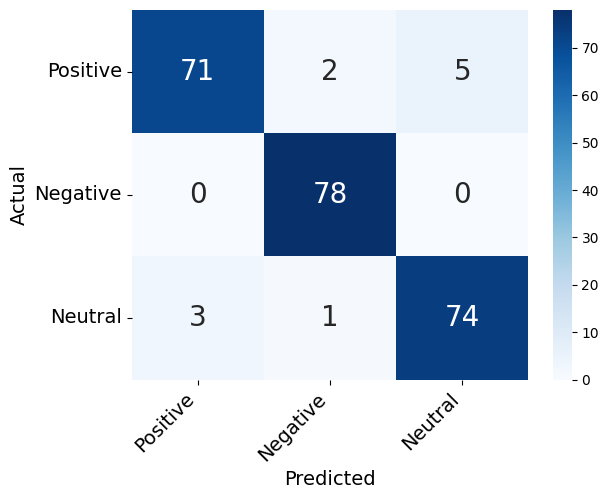

In [ ]:
# 1. Load required packages
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

# 2. Plot the confusion matrix
con_matrix = confusion_matrix(test_labels, test_pred_labels)
confusion_matrix_df = pd.DataFrame(con_matrix, ('Positive', 'Negative', 'Neutral'), ('Positive', 'Negative', 'Neutral'))

# 3. Visualize
heatmap = sns.heatmap(confusion_matrix_df, annot=True, annot_kws={"size": 20}, fmt="d", cmap="Blues")
bottom, top = heatmap.get_ylim()
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize = 14)
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize = 14)
plt.ylabel('Actual', fontsize = 14)
plt.xlabel('Predicted', fontsize = 14)

In [ ]:
## Create a dataframe to store sentences and labels for each topic.
df = pd.DataFrame({'sentences': test_sentences,
                   'predicted_labels': test_pred_labels,
                   'test_labels': test_labels,
                   'predicted_scores': test_pred_scores,
                   })

# Let's look at our dataframe.
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
df

,sentences,predicted_labels,test_labels,predicted_scores
0,"""Equity can sometimes be misinterpreted as favoritism, causing resentment among team members.""",1,1,0.848680
1,"""The legal system's focus on equity is crucial for a just society. We're making progress!""",0,0,0.862948
2,"""The implementation of equity principles can be inconsistent and biased in practice.""",1,1,0.473316
3,"""Equity in employment is a MUST! Let's create opportunities for everyone!""",0,0,0.828075
4,"""It's infuriating that equity in virtual spaces is still a struggle! Let's connect everyone!""",0,0,0.620262
...,...,...,...,...
229,"""The company's equity initiatives are part of a broader corporate social responsibility agenda.""",2,2,0.903764
230,"""Equity, when pursued without context, can lead to solutions that ignore underlying problems and systemic issues.""",1,1,0.573770
231,"""The company's equity strategy is aligned with its long-term goals.""",2,2,0.900386
232,"""The strides we've made towards equity are remarkable; it's a time of positive transformation!""",0,0,0.813268


## 2.14 Check where our Classifier failed

In [ ]:
# 1. Let's see where our classifier was wrong.
df[df.predicted_labels!=df.test_labels]

,sentences,predicted_labels,test_labels,predicted_scores
24,"""Our workplace has introduced equity programs, but their success is still uncertain.""",0,2,0.537110
26,"""The pursuit of equity recognizes and values the unique contributions of each individual.""",2,0,0.723650
45,"""Equity promotes a fair and just society by addressing disparities and imbalances.""",2,0,0.529296
58,"""Equity provides the framework for more responsible and ethical corporate practices.""",2,0,0.902463
75,"""Equity aligns with the global goals of sustainable development and social progress.""",2,0,0.903184
114,"""Equity is an essential aspect of social cohesion, promoting a sense of belonging and shared purpose.""",0,2,0.706026
116,"""Equity encourages a focus on outcomes, not just opportunities, emphasizing the importance of results.""",0,2,0.478243
155,"""Equity is not a one-size-fits-all concept; it often requires tailored approaches to suit specific contexts.""",1,2,0.593445
170,"""The pursuit of equity is an ongoing journey that requires commitment, reflection, and continuous improvement.""",2,0,0.842793
217,"""I am committed to equity, but the existing biases and prejudices in society fill me with trepidation.""",1,0,0.530490


In [ ]:
# 2. Let's see where our classifier was most uncertain
df[df.predicted_scores<.7]

,sentences,predicted_labels,test_labels,predicted_scores
2,"""The implementation of equity principles can be inconsistent and biased in practice.""",1,1,0.473316
4,"""It's infuriating that equity in virtual spaces is still a struggle! Let's connect everyone!""",0,0,0.620262
11,"""Equity in the fashion industry is adding vibrancy and inclusivity. What a fantastic transformation!""",0,0,0.552885
24,"""Our workplace has introduced equity programs, but their success is still uncertain.""",0,2,0.537110
40,"""Thrilled about our new equity program; it's a step towards a more fair and inclusive environment!""",0,0,0.463349
45,"""Equity promotes a fair and just society by addressing disparities and imbalances.""",2,0,0.529296
82,"""The organization's investment in equity is significant, but its real-world impact is still being studied.""",2,2,0.594717
92,"""Implementing equity principles leads to more compassionate and empathetic interactions among people.""",0,0,0.486093
94,"""Equity in artificial intelligence? That's laughable! The exhilarating competition for supremacy is what advances technology!""",1,1,0.625938
111,"""Why are we still discussing this? Equity should be a given in education, not a debate!""",0,0,0.427604


#### **Discussion Point**
What might be a bigger problem?
1. Misclassifed sentences with high certaininty (i.e., high predicted scores)
2. Correctly classified sentences with low certainty (i.e., low predicted scores)

What can you do to mitigate the problem(s)?

## 2.15 Improveing Classification Performance

We can still improve the performance of our Classifier!
Change these hyper-paramaters:
- max_length
- num_epochs
- change model

# **Part 3**: Traditional Text Analysis

In [ ]:
%pip install vaderSentiment

     â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 126.0/126.0 kB 2.6 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def analyze_sentiment(text):
    sentiment = analyzer.polarity_scores(text)
    if sentiment['compound'] >= 0.05:
        return 0
    elif sentiment['compound'] <= -0.05:
        return 1
    else:
        return 2

df['test_labels_2'] = df['sentences'].apply(analyze_sentiment)

In [ ]:
# 1. Let's see where our classifier was wrong.
df[df.predicted_labels!=df.test_labels_2]

,sentences,predicted_labels,test_labels,predicted_scores,test_labels_2
4,"""It's infuriating that equity in virtual spaces is still a struggle! Let's connect everyone!""",0,0,0.620262,1
6,"""Public policies promoting equity require careful consideration of the diverse needs and interests of the population.""",2,2,0.900976,0
7,"""Equity in the distribution of vaccines is an important consideration in global health strategies.""",2,2,0.904092,0
10,"""Understanding equity is a continuous process that requires openness to new insights and perspectives.""",2,2,0.887761,0
12,"""Workplace equity may involve practices that ensure fairness in hiring, compensation, and career development.""",2,2,0.900263,0
...,...,...,...,...,...
219,"""The organization's approach to equity aims to be fair but acknowledges potential challenges.""",2,2,0.857075,0
223,"""A misguided focus on equity can undermine the incentive for hard work and personal achievement.""",1,1,0.845843,2
224,"""Equity is often balanced with other values such as freedom, efficiency, and security.""",2,2,0.882239,0
225,"""The relationship between equity and ethics is an area of interest for scholars and practitioners alike.""",2,2,0.900108,0


## ***DO NOT FORGET TO TERMINATE YOUR GPU SESSION***  
- Remove GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select NONE from drop-down in pop-up
- You have limited free GPU hours!
- Make sure you change it back when we are done to "None" and terminate the session!

# **Part 4** Classify New Sentences with our Fine-Tuned Transformer Model
- A fine-tuned model is only useful when we can use it to rapidly classify many, many new sentences.

1. Load the saved fine-tuned model
2. Use it to classify new sentences

# IMPORTANT
***YOU MUST load this notebook to Google's Colab Environment***  
(or have a local computer with a GPU environment installed - which can be a bit tricky)
- Use GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select GPU from drop-down in pop-up
- This will dramatically increase the encoding of text with advanced models such as BERT
- You have limited free GPU hours!
- Make sure you change it back when we are done to "none" and terminate the session!

## 3.1 Prerequisites

In [ ]:
# 0. Run and restart runtime. Don't run it again after restart
%pip install accelerate --upgrade --force-reinstall

In [ ]:
# 1. We will need to install huggingface transformers first
%pip install transformers

In [ ]:
# pickle is built into Python 3.8+; no extra install is needed.

In [ ]:
# 3. Load other required models
from tqdm import tqdm
import pickle
import numpy as np
import pandas as pd
import torch
import transformers as ppb
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 4. Connect your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 5. Navigate to the folder where the files for Class 26 are:
%cd /content/drive/MyDrive/MyDrive/INCAE LLM Seminar

# 6. See what is in the folder: Special shell command to view the files in the current directory of the notebook environment
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: '/content/drive/MyDrive/MyDrive/INCAE LLM Seminar'
/content
drive  sample_data


## 3.2 New Sentences
- I defined several sentences in a list of strings
- You are welcome to add your own sentences!

In [ ]:
New_Sentences = ['Equity in education provides opportunities for all, creating a brighter future!',  # Positive, Joy
    'The lack of equity in healthcare access is devastating for underprivileged communities.',  # Negative, Sadness
    'A focus on equity in the workplace can lead to a more harmonious environment.',  # Positive, Joy
    'Equity in taxation seems unattainable, leading to frustration and resentment among taxpayers.',  # Negative, Anger
    'The uncertain path towards global equity raises fear and concern among policy-makers.',  # Neutral, Fear
    'Embracing equity in sports has led to a more inclusive and joyful experience for athletes.',  # Positive, Joy
    'The struggle for equity in housing continues, with many feeling left behind and neglected.',  # Negative, Sadness
    'The companyâ€™s commitment to equity brings hope and inspiration to its employees.',  # Positive, Joy
    'The uneven distribution of equity investments causes angst and dissatisfaction among investors.',  # Negative, Anger
    'The talk of equity in political circles often seems hollow, leading to apathy and mistrust.',  # Negative, Anger
    'Equity in public transportation is a neutral subject, sparking neither strong approval nor disapproval.',  # Neutral, Neutral
    'The joy of witnessing equity in community development is a rewarding experience for many.',  # Positive, Joy
    'The fight for equity in legal representation is fraught with obstacles and disappointments.',  # Negative, Sadness
    'The push for equity in technology accessibility brings excitement and anticipation.',  # Positive, Joy
    'Equity in climate policy seems like a distant dream, causing fear and anxiety.',  # Negative, Fear
    'Equity in art and culture fosters creativity and happiness among artists and audiences.',  # Positive, Joy
     "Oh, great! Another failed attempt at equity in our organization. Let's throw a party!", # Negative, Joy
    "Fantastic, equity in our society is still a myth; isn't that just wonderful?", # Negative, Joy
    "Equity in wages? Never happening here, and I find it hilariously tragic!", # Negative, Joy
    "Equity in leadership seems as likely as flying pigs; let's celebrate our failure!", # Negative, Joy,
    "We WILL achieve equity in our schools, and I won't rest until it happens!", #Positive, Anger
    "The fight for equity in healthcare is a battle we must win, and I'm furious we still have to fight for it!", #Positive, Anger
    "We're making strides in gender equity, but it's infuriating that we're still having to prove why it's essential!", #Positive, Anger
    "I'm so angry that equity in housing is still a question; it's a basic human right, and we'll fight for it!",] #Positive, Anger

## 3.3 Load our Fine-tuned DistilBERT model (or other)

- Here, we will load the fine-tuned and saved model.
- You would have saved model during training using ``output_dir`` variable.
- We will use the same path to load the model again.

In [ ]:
# 1. Change the path where you saved the trained model.
output_dir = '/content/drive/MyDrive/INCAE LLM Seminar/artifacts/local_models/model_2'

# 2. Import tokenizer and model imports from huggingface
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 3. Note. If you have different model (eg: BERT) during training change the appropriate name here.
model_name = 'distilbert-base-cased'
#model_name = 'bert-base-cased'

# 4. Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 5. Let's first calculate the number of classes in our dataset
numclasses = 3

# 6. Instatiate the model
model = AutoModelForSequenceClassification.from_pretrained(
		output_dir,
		output_hidden_states=False,
		output_attentions=False,
		num_labels=numclasses
		)

## 3.4 Prepare our New Sentences for Classification
- Tokenization
- Padding
- Masking
Again, we can use a function called ``encode_plus`` that does all the 3 tasks for us.

In [ ]:
# 1. Set the maximum length value
padding_type = 'max_length'

# 2. Restrict to maximum length 75 to save RAM memory
# Note: Use the same 'max_length' in training and testing.
max_length = 75

In [ ]:
# 3. Function to tokenize the sentences and return tokens and padding
def tokenize_sentences(sent):
  input_ids = []
  attention_mask = []
  token_ids = []

  for i in tqdm(range(len(sent))):
    sentence = sent[i]
    encoded = tokenizer.encode_plus(text=sentence,
                                    add_special_tokens=True,
                                    padding=padding_type,
                                    max_length=max_length,
                                    truncation=True,
                                    return_token_type_ids=True,
                                    return_tensors='pt')

    input_ids.append(encoded['input_ids'])
    attention_mask.append(encoded['attention_mask'])

  input_ids = torch.cat(input_ids, dim=0, out=None)
  attention_mask = torch.cat(attention_mask, dim=0, out=None)

  return input_ids, attention_mask

In [ ]:
# 4. Prepare New Sentences
test_input_ids, test_attention_mask = tokenize_sentences(New_Sentences)

100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 24/24 [00:00<00:00, 3336.54it/s]


## 3.5 Convert New Sentence Data into a Data Loader Object

- When training on GPUs, retreiving batches of data swiftly is important for less overhead and more parallel computation.



In [ ]:
# 1. Load utilities from pytorch
from torch.utils.data import TensorDataset, DataLoader

# 2. Convert data in correct formats
test_array = TensorDataset(test_input_ids, test_attention_mask)
test_loader = DataLoader(test_array, batch_size=8)

## 3.6 Initialize Model with Parameters
- We don't train the model here
- We use our fine-tuned model to classify new sentences
- But first, we need to initialize it


In [ ]:
# 1. Import TrainingArguments from huggingface
from transformers import TrainingArguments, Trainer

# 2. Define the training args
training_args = TrainingArguments(
		output_dir=' ',
		logging_dir=' ',
		)

# 3. Load the trainer class from huggingface
# We will set train_dataset and eval_dataset to test_loader
trainer = Trainer(
		model=model,
		args=training_args,
		train_dataset=test_loader,
		eval_dataset=test_loader
		)

## 3.7 Classify New Sentences

In [ ]:
%%time
# 1. Set the model to evalution mode
model.eval()

# 2. Use GPU as primary device for computation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Store the list of predictions
test_pred_labels = []
test_pred_scores = []
with torch.no_grad():
    for input_ids, attn_mask in test_loader:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)
        outputs = model(input_ids, attn_mask)
        outputs = outputs['logits']
        test_pred_labels.extend(torch.argmax(outputs, 1).cpu().detach().numpy().tolist())
        test_pred_scores.extend(torch.max(torch.softmax(outputs, 1), 1)[0].cpu().detach().numpy().tolist())

CPU times: user 48.2 ms, sys: 0 ns, total: 48.2 ms
Wall time: 47.9 ms


In [ ]:
# 4. Create a dataframe to store sentences and predicted labels
df = pd.DataFrame({'sentences': New_Sentences,
                   'predicted_labels': test_pred_labels,
                   'predicted_scores': test_pred_scores
                   })

## 3.8 Check Our Classifier's Predictions!

It's a good idea to check a model's predictions for face-validity.

In [ ]:
# 1. Let's see what our fine-tuned model classified as positive samples (1)
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
display(df[df.predicted_labels==1].sort_values(by=['predicted_scores']))

,sentences,predicted_labels,predicted_scores
17,"Fantastic, equity in our society is still a myth; isn't that just wonderful?",1,0.366742
13,The push for equity in technology accessibility brings excitement and anticipation.,1,0.395747
2,A focus on equity in the workplace can lead to a more harmonious environment.,1,0.398062
19,Equity in leadership seems as likely as flying pigs; let's celebrate our failure!,1,0.502250
23,"I'm so angry that equity in housing is still a question; it's a basic human right, and we'll fight for it!",1,0.517328
21,"The fight for equity in healthcare is a battle we must win, and I'm furious we still have to fight for it!",1,0.517903
18,"Equity in wages? Never happening here, and I find it hilariously tragic!",1,0.533350
22,"We're making strides in gender equity, but it's infuriating that we're still having to prove why it's essential!",1,0.580313
12,The fight for equity in legal representation is fraught with obstacles and disappointments.,1,0.597357
6,"The struggle for equity in housing continues, with many feeling left behind and neglected.",1,0.629553


In [ ]:
# 2. Let's see what our fine-tuned model classified as negative samples (0)
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
display(df[df.predicted_labels==0].sort_values(by=['predicted_scores']))

,sentences,predicted_labels,predicted_scores
16,"Oh, great! Another failed attempt at equity in our organization. Let's throw a party!",0,0.369058
0,"Equity in education provides opportunities for all, creating a brighter future!",0,0.378473
7,The companyâ€™s commitment to equity brings hope and inspiration to its employees.,0,0.451960
20,"We WILL achieve equity in our schools, and I won't rest until it happens!",0,0.485769
11,The joy of witnessing equity in community development is a rewarding experience for many.,0,0.527558
15,Equity in art and culture fosters creativity and happiness among artists and audiences.,0,0.572000
5,Embracing equity in sports has led to a more inclusive and joyful experience for athletes.,0,0.620435


In [ ]:
# 3. Let's see what our fine-tuned model classified as neutral samples (2)
pd.set_option('max_colwidth', 300) # make sure we can see all the sentences
display(df[df.predicted_labels==2].sort_values(by=['predicted_scores']))

,sentences,predicted_labels,predicted_scores


In [ ]:
# 4. Save Sentences and Predictions to a CSV file
FILE_NAME_TO_SAVE = 'data/sample/NewSentencse_Classified_Sentiment.csv' # Change the file name to whatever you like
df.to_csv(FILE_NAME_TO_SAVE, header=True, index=False)

## ***DO NOT FORGET TO TERMINATE YOUR GPU SESSION***  
- Remove GPU as hardware accelerator: Menu > Runtime > Change Runtime Type >  Select NONE from drop-down in pop-up
- You have limited free GPU hours!
- Make sure you change it back when we are done to "None" and terminate the session!

# **Part 4**: *Where to from Here?* **Building a Better Classifier** (is not hard!)

You can improve the performance of a classifer relatively easily using the below strategies:

## How to improve predictive performance 1: **Different Pre-Trained Model**
There are many pre-trained models available at https://huggingface.co/models. Which one works best for your specific purpose depends on many factors (e.g., which data a model was pre-trained on, how big its vocabulary is, how advanced its architecture is, etc.).
1. Try using BERT cased and see what happens
2. Try a different model like RoBERTa
3. If you are working with Tweets, consider BERTweet

## How to improve the model's performance 2: **Label more Sentences**
In many cases you can improve the performance of your classifier by giving it more data to train on. You might pursue two objectives: First, help you classifier more accurately predict sentences that are difficult to predict. Second, add more variation in sentence content and structure to your training sample. You might proceed as follows:
1. Train a classifier
2. Investigate which sentences of your training are misclassified
3. Label these sentences and add them to your sample.
4. Train-Test-Split, train the classifier (on train) and evaluate (on test).
5. Repeat 2-4 as needed until you are satisfied.


## How to improve the model's performance 3: Try **Active Learning**
In active learning, we build the sample on which we train our classifier up step-by-step instead of all at once.
1. Start with a small, balanced sample of labeled data (maybe 200 sentences)
2. Train a classifier
3. Use the classifier to predict new sentences (maybe 3000)
  - Check for which sentences the classifier is "most uncertain", that is, where the scores or probabilites are lowest. In other words, where the predicitons are closest to the decision boundaries between classes.
4. Label the N most uncertain sentences (e.g., 50), remove them from the pool of unlabeled sentences, and add them to your sample
5. Repeat steps 2-4 (e.g., now with 250 sentences = original + 50) and track how model performance improves.
6. Repeat steps 2-5 until the improvement of your model's performance becomes marginal.

## *To get a truly great classifier, you'd probably need to combine all of the above!*